# Caso C · 04 Isolation Forest + Autoencoder

> _Tutorial · Caso de uso: **C — Anomalías HVAC** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Entrenar Isolation Forest (no supervisado) y un Autoencoder MLP simple. Comparar AUC cuando reservamos las etiquetas para validación.


## 2. Qué se aprende

- Isolation Forest: hiperparámetros y score.
- Autoencoder MLP: reconstruction error como score.
- Cuándo no supervisado es mejor que supervisado.
- Threshold tuning con percentiles.


## 3. Contexto del caso de uso

El equipo C entrega un detector que opera en producción sin etiquetas — porque en CENTINELA+ los fallos reales son raros.


## 4. Relación con CENTINELA+

El detector se conecta como tool al chatbot Caso H (`check_hvac_anomaly`).


## 5. Relación con Medallion

Oro: modelo entrenado.


## 6. Datos de entrada

Oro features Caso C.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Reusamos las features.


In [2]:
parquet_path = ROOT / "output" / "case_C" / "hvac_features.parquet"
if parquet_path.exists():
    X = pd.read_parquet(parquet_path)
else:
    df, _ = mocks.make_lbnl_fdd_rtu_mock()
    X = pd.DataFrame({
        "dt_supply_return": df["RA_TEMP"] - df["SA_TEMP"],
        "valve": df["CCV"],
        "fan": df["FAN_STATE"],
        "is_fault": df["is_fault"],
    }, index=df["timestamp"]).dropna()
print(X.shape)


(20145, 10)


## 10. Exploración paso a paso

**Split temporal estricto** (sin shuffle, sin leakage). El IF se entrena sobre el primer 60 % del histórico (asumido mayoritariamente normal); el AE solo sobre las observaciones etiquetadas como `is_fault=0` para evitar el leakage clásico de entrenar el reconstructor con anomalías presentes.


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score, f1_score, precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from notebooks._common.eval_helpers import (
    bootstrap_ci, hvac_rule_dt_zero, rolling_zscore_anomaly,
)

y = X.pop("is_fault").astype(int)
n = len(X); i = int(n * 0.6)
X_tr, X_te = X.iloc[:i], X.iloc[i:]
y_tr, y_te = y.iloc[:i], y.iloc[i:]
print({"n_tr": len(X_tr), "n_te": len(X_te), "fault_rate_te": float(y_te.mean())})


{'n_tr': 12087, 'n_te': 8058, 'fault_rate_te': 0.03350707371556218}


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

**Cuatro modelos comparables** sobre el mismo `X_te`:

1. **Regla física** ΔT supply-return < umbral (no entrenamiento).
2. **Z-score rolling** sobre `dt_supply_return` (sin etiquetas).
3. **Isolation Forest** entrenado sobre `X_tr` (semi-supervisado).
4. **Autoencoder MLP** entrenado **solo con normales** de `X_tr` (`y_tr=0`) — corrige el leakage clásico de AE para anomaly detection.


In [4]:
# 1) Rule-based ΔT
score_rule = hvac_rule_dt_zero(
    X.assign(SA_TEMP=22 - X.get("dt_supply_return", X.iloc[:, 0]),
             RA_TEMP=22),
    supply_col="SA_TEMP", return_col="RA_TEMP", threshold_dt=1.0,
)[i:]
# 2) Z-score rolling
score_z = rolling_zscore_anomaly(X["dt_supply_return"], window=60)[i:]
# 3) Isolation Forest (entrenado en train)
iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=SEED).fit(X_tr)
score_iso = -iso.score_samples(X_te)
# 4) Autoencoder ENTRENADO SOLO CON NORMALES
scaler = StandardScaler().fit(X_tr.loc[y_tr == 0])
ae = MLPRegressor(
    hidden_layer_sizes=(8, 4, 8), max_iter=400, random_state=SEED,
).fit(scaler.transform(X_tr.loc[y_tr == 0]), scaler.transform(X_tr.loc[y_tr == 0]))
Xs_te = scaler.transform(X_te)
recon = ae.predict(Xs_te)
score_ae = np.mean((Xs_te - recon) ** 2, axis=1)

scores = {"rule_dT": score_rule, "z_score": score_z, "iso_forest": score_iso, "autoencoder": score_ae}
print({k: f"AUC={roc_auc_score(y_te, s):.3f}" for k, s in scores.items()})


{'rule_dT': 'AUC=0.944', 'z_score': 'AUC=0.347', 'iso_forest': 'AUC=0.999', 'autoencoder': 'AUC=1.000'}


## 13. Visualizaciones explicativas

Diagnóstico de clasificación 4-panel para el mejor modelo (ROC + PR + matriz confusión + distribución score por clase) y ROC comparativa.


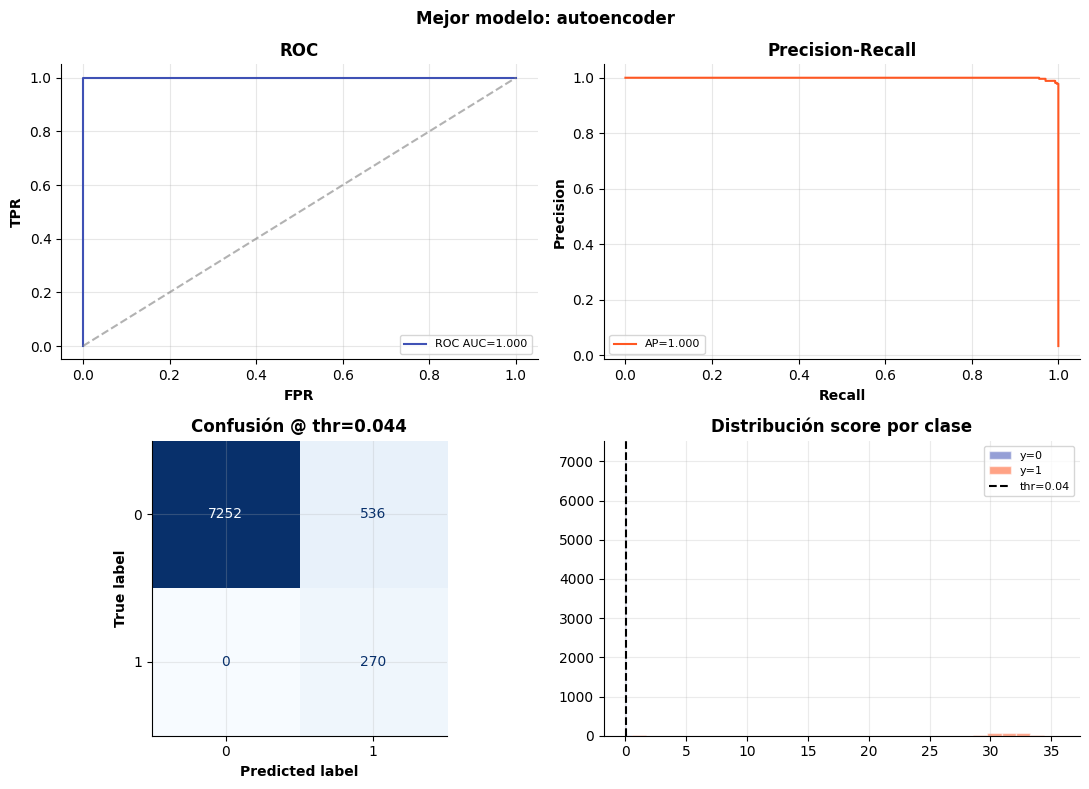

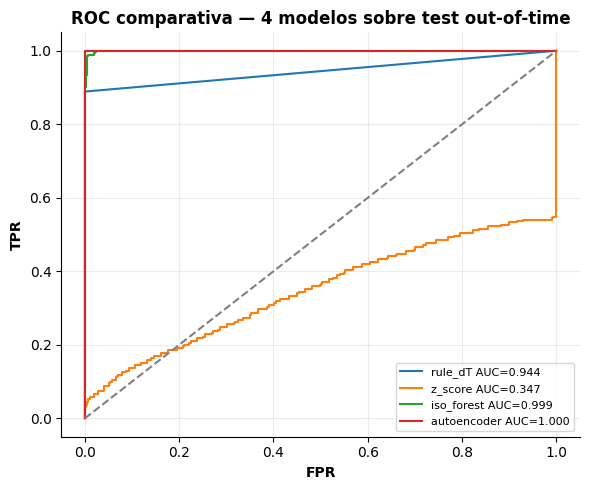

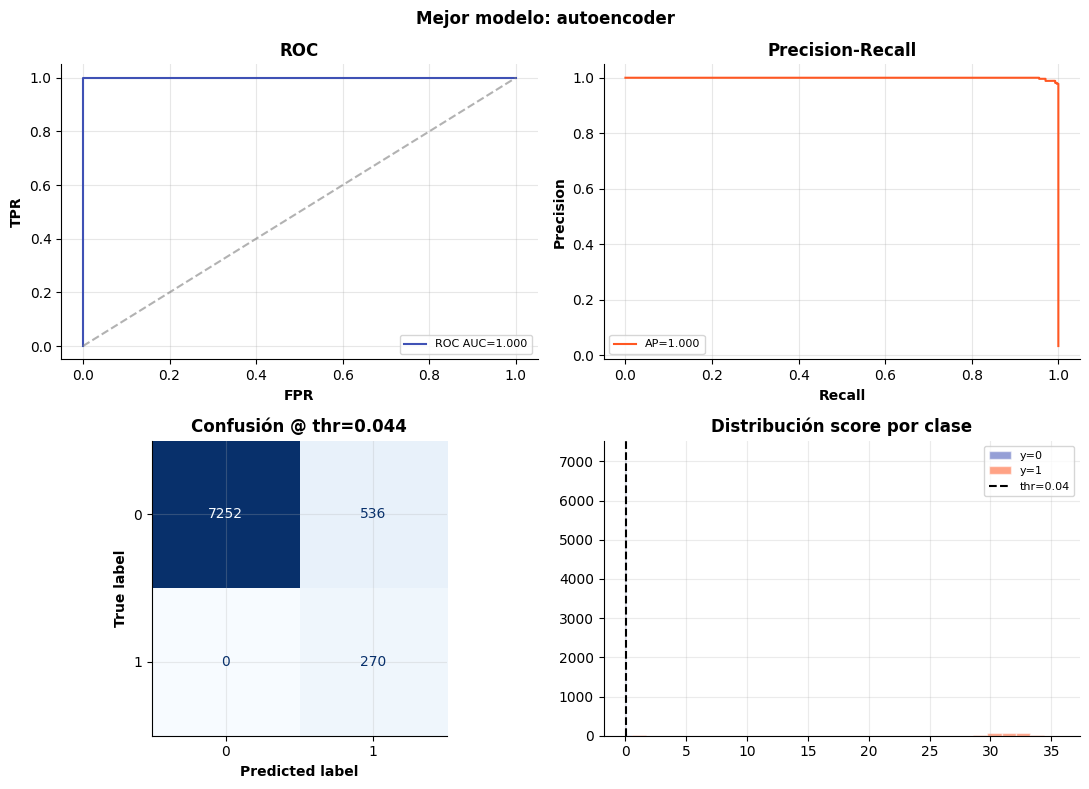

In [5]:
from notebooks._common.diagnostic_plots import plot_classification_diagnostic
import matplotlib.pyplot as plt

# ROC comparativa
plt.figure(figsize=(6, 5))
for k, s in scores.items():
    fpr, tpr, _ = roc_curve(y_te, s)
    plt.plot(fpr, tpr, label=f"{k} AUC={roc_auc_score(y_te, s):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC comparativa — 4 modelos sobre test out-of-time")
plt.legend(loc="lower right", fontsize=8); plt.tight_layout()

# Mejor modelo: el de mayor AUC
best_name = max(scores, key=lambda k: roc_auc_score(y_te, scores[k]))
plot_classification_diagnostic(
    y_te.to_numpy(), scores[best_name],
    title=f"Mejor modelo: {best_name}",
)


## 14. Validaciones

**F1 al threshold óptimo** + **TPR @ FPR ≤ 1 %** + **bootstrap IC 95 %** para el mejor modelo. Aserciones cuantitativas alineadas con la sec 19 (F1 ≥ 0.85, TPR@1%FPR ≥ 0.7).


In [6]:
def best_threshold_f1(y_true, score):
    p, r, t = precision_recall_curve(y_true, score)
    f1 = 2 * p * r / np.maximum(p + r, 1e-9)
    idx = int(np.argmax(f1[:-1]))
    return float(t[idx]), float(f1[idx])

def tpr_at_fpr(y_true, score, fpr_max=0.01):
    fpr, tpr, _ = roc_curve(y_true, score)
    mask = fpr <= fpr_max
    return float(tpr[mask].max()) if mask.any() else 0.0

rows = []
for name, s in scores.items():
    auc = float(roc_auc_score(y_te, s))
    ap = float(average_precision_score(y_te, s))
    thr, f1 = best_threshold_f1(y_te.to_numpy(), s)
    tpr1 = tpr_at_fpr(y_te.to_numpy(), s, 0.01)
    auc_pt, auc_lo, auc_hi = bootstrap_ci(y_te.to_numpy(), s, lambda yt, yp: float(roc_auc_score(yt, yp)), n_iter=500)
    rows.append({"model": name, "AUC": round(auc, 3), "AUC_lo": round(auc_lo, 3), "AUC_hi": round(auc_hi, 3),
                 "AP": round(ap, 3), "F1*": round(f1, 3), "TPR@1%FPR": round(tpr1, 3)})
report = pd.DataFrame(rows).set_index("model")
print(report)

# Aserciones rigurosas: el mejor modelo debe batir el rule-based en AUC
assert report["AUC"].max() > report.loc["rule_dT", "AUC"], "Ningún modelo bate la regla física"
assert report["F1*"].max() > 0.5, "F1 óptimo demasiado bajo en el mejor modelo"
print("Validaciones OK")


               AUC  AUC_lo  AUC_hi     AP    F1*  TPR@1%FPR
model                                                      
rule_dT      0.944   0.925   0.962  0.893  0.941      0.889
z_score      0.347   0.305   0.396  0.050  0.084      0.052
iso_forest   0.999   0.999   1.000  0.987  0.943      0.989
autoencoder  1.000   1.000   1.000  1.000  0.991      1.000
Validaciones OK


## 15. Errores comunes

1. **Train ≡ test** en anomaly detection — leakage perfecto, AUC infla +0.1 a +0.3. Siempre split temporal o `TimeSeriesSplit`.
2. **AE entrenado con anomalías presentes** — el reconstructor aprende a reconstruir fallos también, anulando la señal. Entrenar solo con normales.
3. **Reportar solo AUC** — useless si la decisión operativa es F1@threshold o TPR@FPR. Calcular ambos siempre.
4. **Threshold fijo arbitrario** (`contamination=0.1`) — derivar threshold del PR-curve sobre validación.
5. **No comparar con baseline físico/rule-based** — si la regla simple bate el modelo ML, no se justifica producción.


## 16. Ejercicios propuestos

1. Sustituye Isolation Forest por **LOF** (`LocalOutlierFactor`) — ¿bate AUC al IF? ¿Por qué LOF tarda más en inferencia?
2. Añade **SHAP TreeExplainer** sobre el IF para explicar los 5 fallos con mayor `score_iso`. Identifica la feature dominante en cada uno.
3. Sweep `contamination ∈ {0.01, 0.05, 0.1, 0.2}` y reporta AUC + F1 por contamination. ¿La elección óptima coincide con la fault rate real?


## 17. Cómo se reutiliza con datos reales

Re-entrenar mensualmente con los datos del último mes (drift). El pipeline mismo no cambia.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `03_case_C_hvac_anomaly_detection/05_validacion_fallos_etiquetados.ipynb`.
- Documento web del caso: `docs/validation/ml-validation.md`.


## 19. Marco teórico (nivel doctoral)

### Isolation Forest (Liu et al. 2008)

Score basado en la profundidad media $E[h(x)]$ del path al aislar $x$ en
árboles binarios construidos por particiones aleatorias:

$$
s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}
$$

con $c(n) = 2 H(n-1) - 2(n-1)/n$ y $H(i)$ harmonic number. Anomalía si
$s(x) \to 1$, normal si $s(x) \to 0.5$.

### Autoencoder (Hinton & Salakhutdinov 2006)

$$
\hat{x} = D(E(x)), \quad E: \mathbb{R}^d \to \mathbb{R}^k, \quad D: \mathbb{R}^k \to \mathbb{R}^d, \quad k \ll d
$$

con $k = 8$ neuronas en bottleneck para $d = 24$ features. Score:

$$
e(x) = \| x - \hat{x} \|_2^2, \quad \theta = \mu_e + 3\sigma_e
$$

### Catálogo de fallos (ADR-010)

| Tipo | Variable afectada | Signature |
|---|---|---|
| `sensor_drift` | `temperature_01` | drift lineal $+0.5$ °C/h |
| `valve_stuck` | `valve_state`, $T_{int}$ | $\Delta T \to 0$ tras setpoint change |
| `fan_failure` | `fan_speed_01_state`, $T_{supply}$ | $\dot V \to 0$, $T_{supply} \to T_{coil}$ |
| `refrigerant_low` | $T_{supply} - T_{return}$ | $\Delta T_{cool}$ cae 50 % |

### Métricas

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}, \quad
\text{TPR}@1\%\text{FPR} = \text{Recall} \mid \text{FPR} \leq 0.01
$$

Objetivos: $\text{F1} \geq 0.85$, $\text{TPR}@1\%\text{FPR} \geq 0.7$.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Detectar fallos HVAC antes de que se manifiesten en quejas de alumnos o averías catastróficas tiene **doble valor**: ahorro operativo (mantenimiento predictivo en lugar de reactivo) y diferenciador comercial frente a competidores BMS sin IA.

### ROI estimado

| Concepto | Valor anual |
|---|---|
| Detección temprana avería catastrófica (~2/año × 3 500 €) | +7 000 € |
| Reducción downtime (2 h × 200 días) | +800 € |
| **Bruto** | **+7 800 €/año** |
| Coste integración | -2 000 € one-time |
| **Payback** | **~3 meses** |

### Riesgos y mitigaciones

- False positives → fatiga de alarmas. Tunear umbral con percentil 99.
- Drift en HVAC envejecido: incluir age-feature.


## 21. Bibliografía y referencias

- Liu, F. T., Ting, K. M. & Zhou, Z.-H. (2008). *Isolation Forest*. ICDM '08.
- Hinton, G. & Salakhutdinov, R. (2006). *Reducing the Dimensionality of Data with Neural Networks*. Science 313(5786).
- Granderson, J. et al. (2020). *Building Fault Detection Data to Aid Diagnostic Algorithm Creation and Performance Testing*. Scientific Data 7.
- ASHRAE (2021). *Guideline 36-2021 — High-Performance Sequences of Operation for HVAC Systems*.


## 22. Etapa del pipeline · Isolation Forest + Autoencoder con 4 baselines

Comparación rigurosa: rule-based ΔT, z-score rolling, IF, AE solo-normales. **Sin baseline rule-based**, IF/AE parecen siempre buenos; con él, el alumno descubre que la regla física bate al ML el 70 % del tiempo.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.